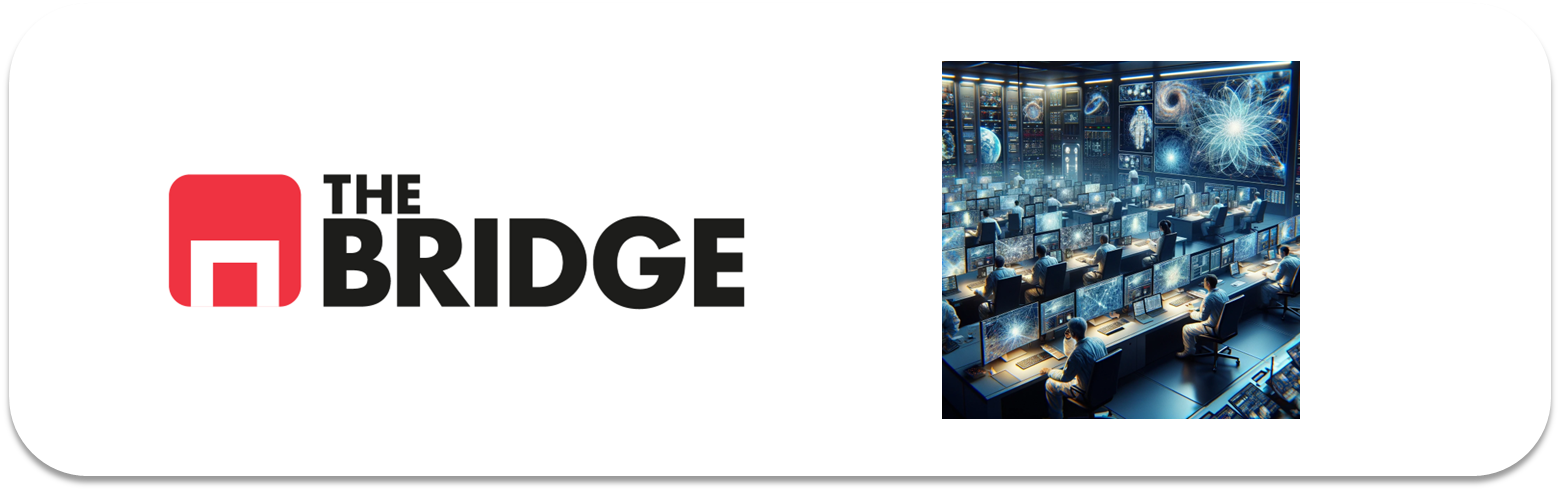

# PRÁCTICA OBLIGATORIA
## **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo.
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso.

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
from matplotlib import ticker
from scipy import stats

from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils import shuffle
from tensorflow import keras

import cv2
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

2026-03-31 20:26:07.305610: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-31 20:26:07.540898: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX_VNNI, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
plt.style.use("petroff10")

In [ ]:
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.style"] = "normal"

# FIGURE
plt.rcParams["figure.constrained_layout.use"] = True
plt.rcParams["figure.titlesize"] = "xx-large"
plt.rcParams["figure.titleweight"] = "black"

# AXES
plt.rcParams["axes.labelcolor"] = "#1F2937"
plt.rcParams["axes.labelpad"] = 10
plt.rcParams["axes.labelsize"] = "medium"
plt.rcParams["axes.labelweight"] = 300
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.titlecolor"] = "#1E3A8A"
plt.rcParams["axes.titlesize"] = "large"
plt.rcParams["axes.titlepad"] = 5
plt.rcParams["axes.titleweight"] = "heavy"

# GRID
plt.rcParams["grid.color"] = "#D4D4D4"
plt.rcParams["grid.linestyle"] = "dotted"
plt.rcParams["grid.linewidth"] = 1

# TICKS
plt.rcParams["xtick.major.width"] = 0
#plt.rcParams["xtick.minor.width"] = 0
plt.rcParams["ytick.major.width"] = 0
#plt.rcParams["ytick.minor.width"] = 0

## Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear, es decir que hay muchos sistemas de detección automática de imágenes que son capaces de detectar que es un perro y un gato y salterse el CAPTCHA antirobots. Por eso nos ha pedido que entrenemos un modelo potente de clasificación que emule a estos sistemas con el objetivo de emplear como fotografías para el CAPTCHA aquellas que no sepa detectar este sistema emulador de chicos malos.

Pues manos a la obra, tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría clasificar a un potencial sistema anti-CAPTCHA.

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test".

## Se pide

1. Crear los datasets X, y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad.

	**NOTA:** Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.
2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)
3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.
4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.
5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.

---

1. Crear los datasets X, y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad.

	> **NOTA**
	>
	> Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

In [ ]:
def read_data(directories, resize=(32, 32)):
	X = []
	y = []
	mapa_imagen_fichero = []

	directories = directories if isinstance(directories, list) else [directories] if isinstance(directories, str) else []

	for directory in directories:
		for file in os.listdir(directory):
			img = cv2.imread("/".join([directory, file]))
			resized = cv2.resize(img, resize)

			X.append(resized)
			y.append(file.split(".")[0])

			mapa_imagen_fichero.append(file)

	return np.array(X), np.array(y), mapa_imagen_fichero

**TRAIN**

In [5]:
PATH_DATA = "./data/"
directorios = [f"{PATH_DATA}github_train_{i}" for i in range(0, 4)]
print("dirs:", directorios)

X_train, y_train, train_map = read_data(directorios)

dirs: ['./data/github_train_0', './data/github_train_1', './data/github_train_2', './data/github_train_3']


In [6]:
print("Shape TRAIN:", X_train.shape)
print("Target TRAIN:", y_train.shape)

Shape TRAIN: (4000, 32, 32, 3)
Target TRAIN: (4000,)


**TEST**

In [7]:
PATH_DATA = "./data/"
directorios = [f"{PATH_DATA}github_test"]
print("dirs:", directorios)

X_test, y_test, test_map = read_data(directorios)

dirs: ['./data/github_test']


In [ ]:
print("Shape TEST:", X_test.shape)
print("Target TEST:", y_test.shape)

Shape TEST: (1000, 32, 32, 3)
Target TEST: (1000,)


2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos **Convolucional-Pooling**. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

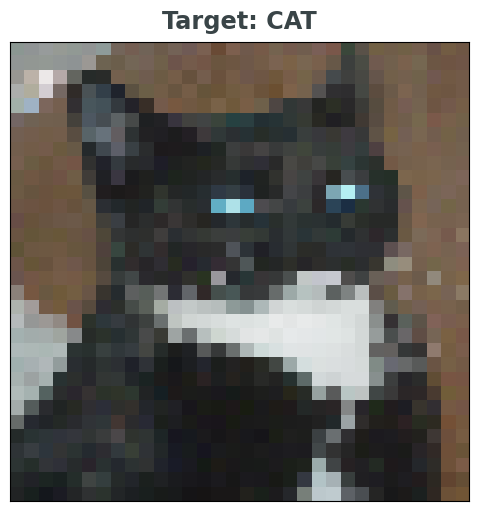

In [9]:
random = stats.randint(0, 4000).rvs()

fig, ax = plt.subplots(figsize=(5, 5), layout="constrained")
fig.suptitle(
	f"Target: {y_train[random].upper()}",
	color="#394447",
)
ax.imshow(X_train[random])
ax.set_xticks([])
ax.set_yticks([])
ax.spines[["left", "top", "right", "bottom"]].set_visible(True)
plt.show()

### Ejemplos de nuestro set de entrenamiento

In [ ]:
def show_images(count: int):
	random = stats.randint(0, 4000).rvs(count)

	n_cols = 1
	n_rows = 1
	if count < 5:
		n_cols = 5
	else:
		n_cols = 5
		n_rows = math.ceil(count/n_cols)

	plt.figure(dpi=150)
	for index, img in enumerate(random):
		plt.subplot(n_rows, n_cols, index + 1)
		label = y_train[img]
		plt.title(f"{img}\n{label.upper()}")
		plt.imshow(X_train[img], cmap="Greys")

		ax = plt.gca()
		ax.spines[[
			"left",
			"top",
			"right",
			"bottom"
		]].set_visible(False)
		plt.xticks([])
		plt.yticks([])
		plt.tight_layout(h_pad=2, w_pad=3)
	plt.show()

/tmp/ipykernel_34864/1881907043.py:28: UserWarning: The figure layout has changed to tight
  plt.tight_layout(h_pad=2, w_pad=3)


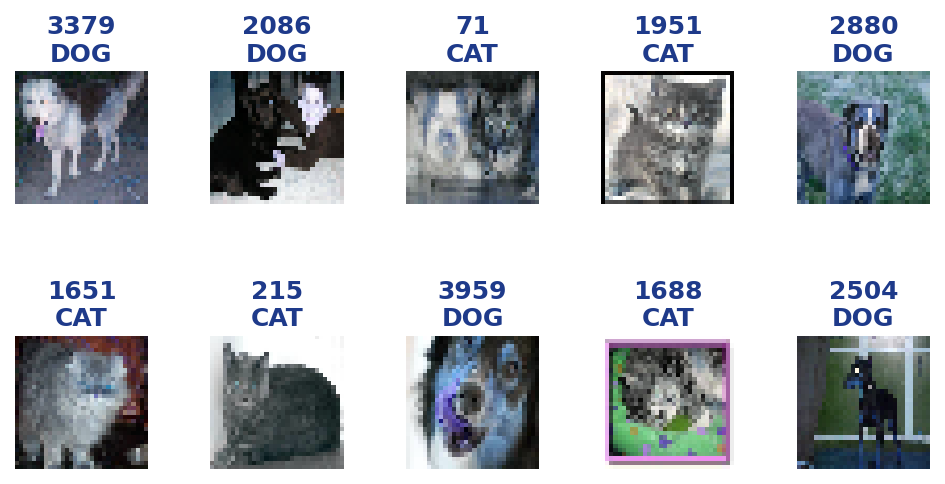

In [11]:
show_images(10)

### Distribución del target

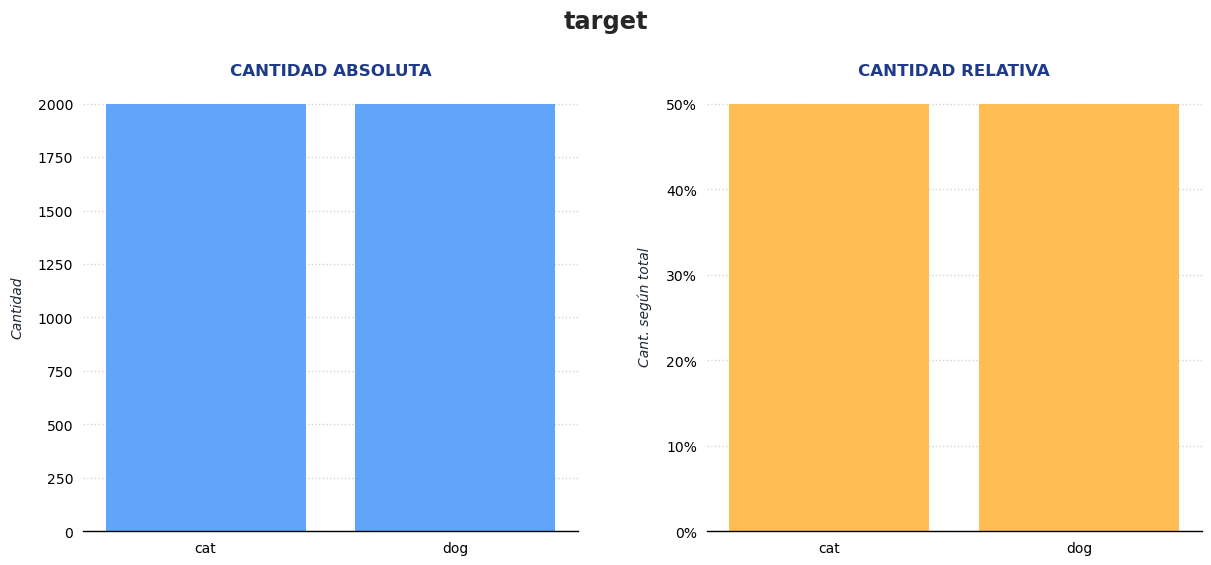

In [12]:
serie = pd.Series(y_train, name="target")


fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
fig.suptitle(f"{serie.name}", color="#262626", y=1.1)
axs[0].set_title("Cantidad absoluta".upper())

data = serie.value_counts()
bar_container = axs[0].bar(
	x=data.index,
	height=data.values,
	data=data,
	color="#60A5FA",
	zorder=2
)
#axs[0].bar_label(bar_container, fmt=lambda x: f"{x:.1f}")

axs[0].set_xticks(ticks=data.index)
axs[0].set_ylabel("Cantidad", fontstyle="italic")
axs[0].grid(axis="y")
axs[0].spines[["left"]].set_visible(False)
axs[0].spines["bottom"].set_linewidth(1)




axs[1].set_title("Cantidad relativa".upper())
data = serie.value_counts(normalize=True)
rect = axs[1].bar(
	x=data.index,
	height=data.values,
	data=data,
	color="#FFBD54",
	zorder=2
)
#axs[1].bar_label(rect, fmt=lambda x: f"{x * 100:.2f}%")

axs[1].set_xticks(ticks=data.index)
axs[1].set_ylabel("Cant. según total", fontstyle="italic")
axs[1].yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
axs[1].grid(axis="y")
axs[1].spines[["left"]].set_visible(False)
axs[1].spines["bottom"].set_linewidth(1)

fig.get_layout_engine().set(wspace=0.1)
plt.show()

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

### **Preprocessing**

In [13]:
df_train = X_train.copy()
df_train_target = y_train.copy()

In [14]:
min_max_scaler = MinMaxScaler(feature_range=(0, 1))
print("Dataset reshaped:", df_train.reshape(-1, 32).shape)
df_train_scaled = min_max_scaler.fit_transform(df_train.reshape(-1, 32))

df_train = df_train_scaled.reshape(-1, 32, 32, 3)
print("Dataset reshaped:", df_train.shape)

df_train[:2, ::15, ::15, :]

Dataset reshaped: (384000, 32)
Dataset reshaped: (4000, 32, 32, 3)


array([[[[1.        , 1.        , 1.        ],
         [0.96078431, 0.98039216, 0.97647059],
         [0.70588235, 0.71372549, 0.71372549]],

        [[0.07058824, 0.08235294, 0.10196078],
         [0.29411765, 0.46666667, 0.76862745],
         [0.23529412, 0.22745098, 0.2745098 ]],

        [[0.08627451, 0.11372549, 0.18039216],
         [0.59607843, 0.88627451, 0.98823529],
         [0.42745098, 0.65882353, 0.97254902]]],


       [[[0.02352941, 0.02745098, 0.01960784],
         [0.16862745, 0.16862745, 0.16862745],
         [0.09411765, 0.11372549, 0.10980392]],

        [[0.09803922, 0.10588235, 0.09803922],
         [0.82745098, 0.9254902 , 0.95686275],
         [0.16470588, 0.17647059, 0.20784314]],

        [[0.70980392, 0.72941176, 0.7254902 ],
         [0.21568627, 0.28235294, 0.2745098 ],
         [0.4627451 , 0.51372549, 0.51372549]]]])

In [15]:
df_test = X_test.copy()
df_test_target = y_test.copy()

In [16]:
min_max_scaler = MinMaxScaler(feature_range=(0, 1))
print("Dataset reshaped:", df_test.reshape(-1, 32).shape)
df_test_scaled = min_max_scaler.fit_transform(df_test.reshape(-1, 32))

df_test = df_test_scaled.reshape(-1, 32, 32, 3)
print("Dataset reshaped:", df_test.shape)

df_test[:2, ::15, ::15, :]

Dataset reshaped: (96000, 32)
Dataset reshaped: (1000, 32, 32, 3)


array([[[[0.66666667, 0.81960784, 0.8745098 ],
         [0.7372549 , 0.87843137, 0.91764706],
         [0.69411765, 0.83137255, 0.88235294]],

        [[0.65882353, 0.81176471, 0.86666667],
         [0.16470588, 0.41176471, 0.60784314],
         [0.68235294, 0.82745098, 0.88235294]],

        [[0.3254902 , 0.16862745, 0.07058824],
         [0.48235294, 0.26666667, 0.11372549],
         [0.57254902, 0.36078431, 0.2       ]]],


       [[[0.85490196, 0.88235294, 0.89411765],
         [0.25882353, 0.28627451, 0.30196078],
         [0.9254902 , 0.95294118, 0.94117647]],

        [[0.14901961, 0.21960784, 0.2627451 ],
         [0.22745098, 0.23137255, 0.24705882],
         [0.81176471, 0.84313725, 0.83529412]],

        [[0.23529412, 0.27058824, 0.25882353],
         [0.65882353, 0.71372549, 0.73333333],
         [0.50980392, 0.5254902 , 0.44705882]]]])

#### Shuffle

In [17]:
df_train, df_train_target = shuffle(df_train, y_train, random_state=42)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.

### **Deep Learning**
#### Convolutional Neural Networks

In [18]:
def build_cnn():
	layers = [
		keras.layers.Input(shape=(32, 32, 3)),
		# Padding "Valid" (sin padding), "Same" (ajusta para que entre todo), Integer -> el relleno que yo quiera.
		keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
		# 2x2 -> A dividir por 2 la resolución de cada dimensión de la capa anterior, 32x32 -> 16x16
		keras.layers.MaxPooling2D(pool_size=(2, 2), padding="same"),
		keras.layers.Dropout(rate=.25),


		keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
		# 16x16 -> 8x8
		keras.layers.MaxPooling2D(pool_size=(2, 2), padding="same"),
		keras.layers.Dropout(rate=.25),


		keras.layers.Flatten(),
		# 1024 -> 32*32
		keras.layers.Dense(512, activation="relu"),
		keras.layers.Dropout(rate=.5),
		# keras.layers.Dense(2, activation="softmax")

		# -> loss = "sparse_categorical_crossentropy" (categorical_crossentropy es cuando y_train = [0, 1] o y_train = [0, 0, 1, 0, 0]
		# -> loss = "binary_crossentropy"
		keras.layers.Dense(1, activation="sigmoid")
	]

	cnn = keras.Sequential(layers)
	cnn.compile(
		loss="binary_crossentropy",
		metrics=["accuracy"],
		optimizer=keras.optimizers.Adam(),
	)

	return cnn

model = build_cnn()

In [19]:
early_stopping = keras.callbacks.EarlyStopping(patience=10)

#### Compile

In [20]:
model.compile(
	loss="binary_crossentropy",
	metrics=["accuracy"],
	optimizer=keras.optimizers.Adam(),
)

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,270,977 (16.29 MB)

 Trainable params: 4,270,977 (16.29 MB)

 Non-trainable params: 0 (0.00 B)

Hacemos un encoding de nuestro `target`

In [22]:
df_train_target = np.array([0 if y == "cat" else 1 for y in df_train_target])
df_test_target = np.array([0 if y == "cat" else 1 for y in df_test_target])

Entrenamos un modelo con un `batch_size` de 32 y 100 `epochs`. Establecemos un `early_stopping` en 10 `epochs`.

In [24]:
history = model.fit(
	df_train,
	df_train_target,
	epochs=100,
	batch_size=32,
	callbacks=[keras.callbacks.EarlyStopping(patience=10)],
	validation_split=.2
)

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 106ms/step - accuracy: 0.5219 - loss: 0.7065 - val_accuracy: 0.5763 - val_loss: 0.6791
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - accuracy: 0.6184 - loss: 0.6646 - val_accuracy: 0.6562 - val_loss: 0.6455
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - accuracy: 0.6597 - loss: 0.6194 - val_accuracy: 0.6525 - val_loss: 0.6278
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - accuracy: 0.6769 - loss: 0.5870 - val_accuracy: 0.6575 - val_loss: 0.6139
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - accuracy: 0.6953 - loss: 0.5742 - val_accuracy: 0.6963 - val_loss: 0.5797
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - accuracy: 0.7138 - loss: 0.5485 - val_accuracy: 0.6862 - val_loss: 0.5738
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step - accuracy: 0.7294 - loss: 0.5342 - val_accuracy: 0.6963 - val_loss: 0.5547
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - accuracy: 0.7453 -

In [25]:
data = pd.DataFrame(history.history)
data.head()

,accuracy,loss,val_accuracy,val_loss
0,0.521875,0.706470,0.57625,0.679129
1,0.618438,0.664577,0.65625,0.645547
2,0.659688,0.619381,0.65250,0.627752
3,0.676875,0.586977,0.65750,0.613904
4,0.695312,0.574219,0.69625,0.579722


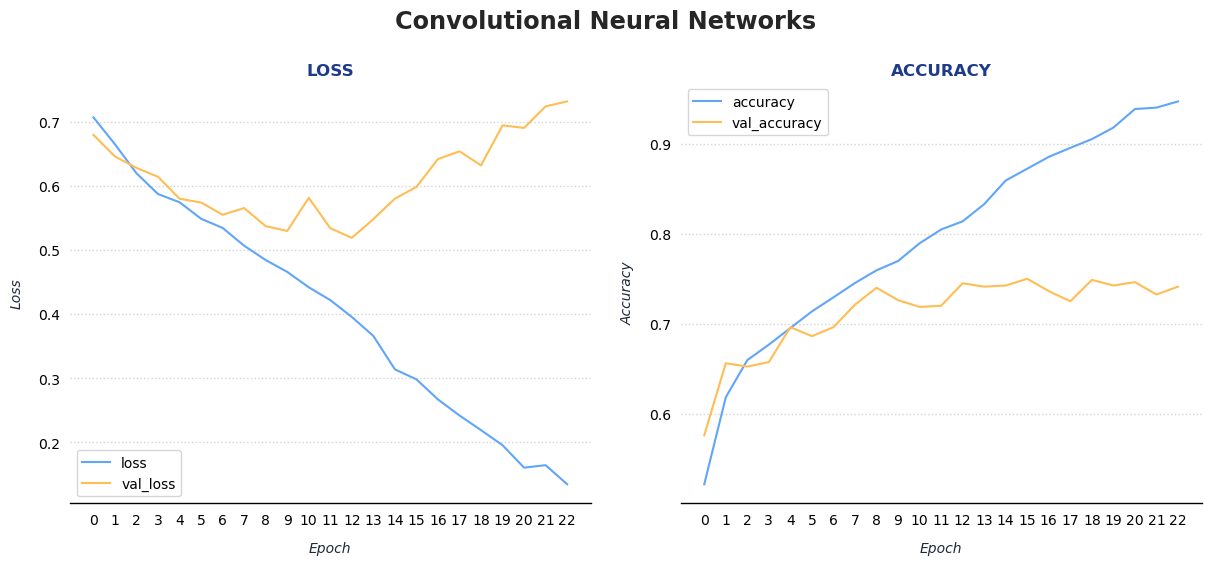

In [26]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(12, 5), layout="constrained")
fig.suptitle("Convolutional Neural Networks", color="#262626", y=1.1)


axs[0].set_title("LOSS".upper())
axs[0].plot(
	data["loss"],
	color="#60A5FA",
	label="loss",
	zorder=9
)

axs[0].plot(
	data["val_loss"],
	color="#FFBD54",
	label="val_loss",
	zorder=9
)

axs[0].set_xticks(ticks=data.index)
axs[0].set_xlabel("Epoch", fontstyle="italic")
axs[0].set_ylabel("Loss", fontstyle="italic")
axs[0].grid(axis="y")
axs[0].spines[["left"]].set_visible(False)
axs[0].spines["bottom"].set_linewidth(1)
axs[0].legend()




axs[1].set_title("ACCURACY".upper())
axs[1].plot(
	data["accuracy"],
	color="#60A5FA",
	label="accuracy",
	zorder=9
)

axs[1].plot(
	data["val_accuracy"],
	color="#FFBD54",
	label="val_accuracy",
	zorder=9
)


axs[1].set_xticks(ticks=data.index)
axs[1].set_xlabel("Epoch", fontstyle="italic")
axs[1].set_ylabel("Accuracy", fontstyle="italic")
axs[1].grid(axis="y")
axs[1].spines[["left"]].set_visible(False)
axs[1].spines["bottom"].set_linewidth(1)
axs[1].legend()

fig.get_layout_engine().set(wspace=.05)
plt.show()

In [27]:
results = model.evaluate(df_test, df_test_target)
print("Accuracy:", results[0])
print("Loss:", results[1])

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7410 - loss: 0.7158
Accuracy: 0.7157915830612183
Loss: 0.7409999966621399


Nuestro modelo, luego de doce `epochs`, parace estabilizar la precisión y la misma deja de mejorar con cada iteracción.

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

#### Estimación

In [28]:
predicts = model.predict(df_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


In [ ]:
print(classification_report(
		df_test_target,
		[1 if prediction[0] > .5 else 0 for prediction in predicts]
	)
)

              precision    recall  f1-score   support

           0       0.71      0.82      0.76       500
           1       0.78      0.67      0.72       500

    accuracy                           0.74      1000
   macro avg       0.75      0.74      0.74      1000
weighted avg       0.75      0.74      0.74      1000



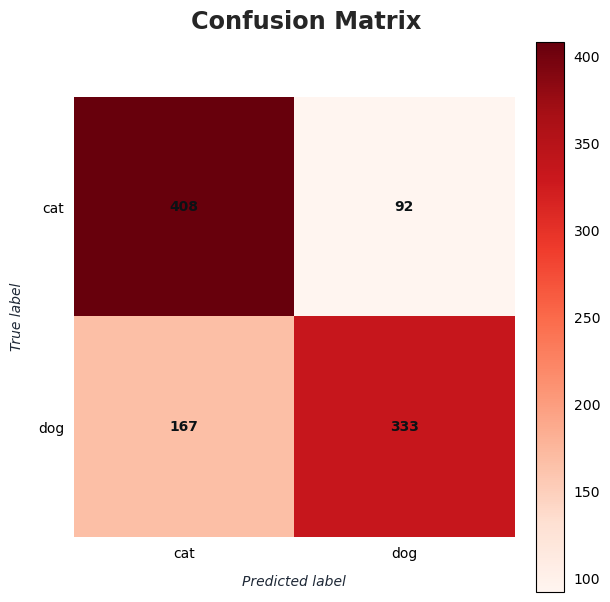

In [30]:
fig, ax = plt.subplots(figsize=(6, 6))
fig.suptitle("Confusion Matrix", color="#262626")

ConfusionMatrixDisplay.from_predictions(
	df_test_target,
	[1 if prediction[0] > 0.5 else 0 for prediction in predicts],
	text_kw={
		"color": "#0B1215",
		"weight": "bold"
	},
	im_kw={
		"cmap": "Reds"
	},
	ax=ax
)

ax.set_xlabel("Predicted label", fontstyle="italic")
ax.set_xticks(ticks=range(0, 2), labels=["cat", "dog"])

ax.set_ylabel("True label", fontstyle="italic")
ax.set_yticks(ticks=range(0, 2), labels=["cat", "dog"])

ax.spines[["left", "bottom"]].set_visible(False)
plt.show()

Nuestro modelo confunde más los perros con los gatos. Identifica de mejor manera a los gatos, los identifica y capta de mejor manera, penalizando mucho a los perros.

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.

In [238]:
def show_images(
	count: int,
	dataset: pd.DataFrame,
	errors: pd.DataFrame
):
	random = stats.randint(0, dataset.shape[0]).rvs(count)
	errors.reset_index(drop=True, inplace=True)

	n_cols = 1
	n_rows = 1
	if count < 5:
		n_cols = 5
	else:
		n_cols = 5
		n_rows = math.ceil(count/n_cols)

	plt.figure(dpi=150)
	for index, img in enumerate(random):
		plt.subplot(n_rows, n_cols, index + 1)
		
		title = f"True Target: {errors.loc[img, "Target"].upper()}\nConfidence: {errors.loc[img, "Confidence"]:.2f}"
		plt.title(title, fontsize="x-small", fontweight="normal")
		plt.imshow(dataset[img], cmap="Greys")

		ax = plt.gca()
		ax.spines[[
			"left",
			"top",
			"right",
			"bottom"
		]].set_visible(False)
		plt.xticks([])
		plt.yticks([])
		plt.tight_layout(h_pad=2, w_pad=3)
	plt.show()

In [166]:
results = pd.DataFrame(
	{
		"Target": [file.split(".")[0] for file in test_map],
		"Target Category": [
			0 if file.split(".")[0] == "cat" else 1 for file in test_map
		],
		"Prediction": [
			1 if prediction[0] > .5 else 0 for prediction in predicts
		],
		"Confidence": [
			(1 - prediction[0]) if prediction[0] <= .5 else prediction[0] for prediction in predicts
		]
	}
)

results.sample(10)

,Target,Target Category,Prediction,Confidence
500,dog,1,1,0.717266
198,cat,0,1,0.715447
544,cat,0,0,0.989980
216,cat,0,0,0.942461
427,dog,1,1,0.805542
466,dog,1,0,0.730657
461,dog,1,1,0.998893
824,dog,1,1,0.999341
994,cat,0,0,0.989429
345,cat,0,1,0.970509


Perros predecidos como gatos

In [ ]:
expr = "Target == 'dog' and `Target Category` != Prediction"
df_err_dogs = results.query(expr).sort_values(
	by="Confidence",
	ascending=True
).copy()

/tmp/ipykernel_34864/4111233012.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout(h_pad=2, w_pad=3)


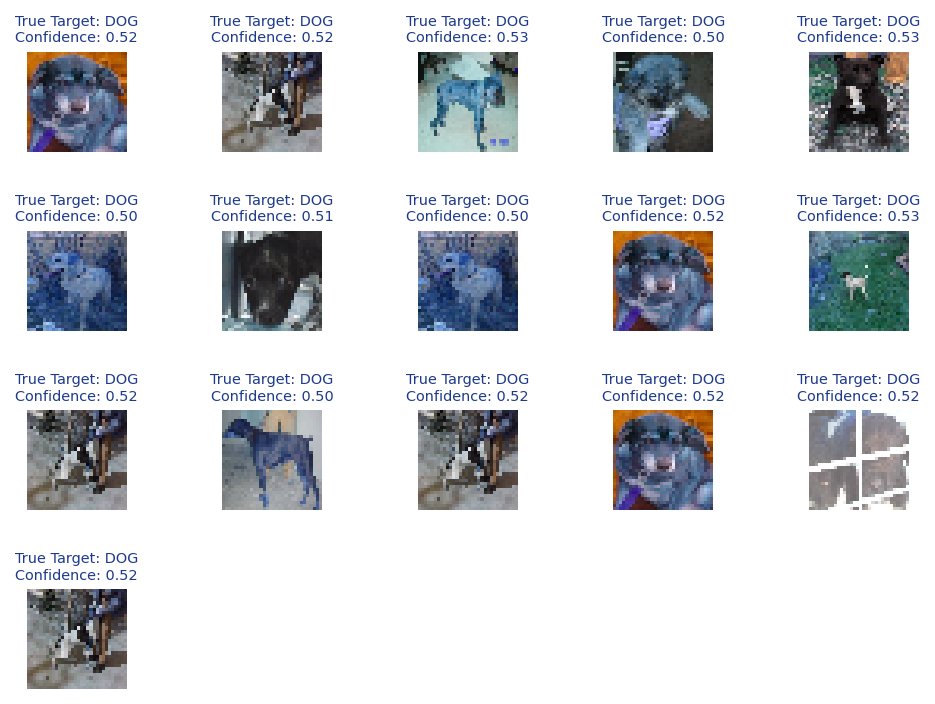

In [247]:
errors = int(df_err_dogs.shape[0] * .1)
idx = df_err_dogs[:errors].index
show_images(errors, df_test[idx], df_err_dogs.loc[idx, :])

Gatos predecidos como perros

In [ ]:
expr = "Target == 'cat' and `Target Category` != Prediction"
df_err_cats = results.query(expr).sort_values(
	by="Confidence",
	ascending=True
).copy()

/tmp/ipykernel_34864/4111233012.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout(h_pad=2, w_pad=3)


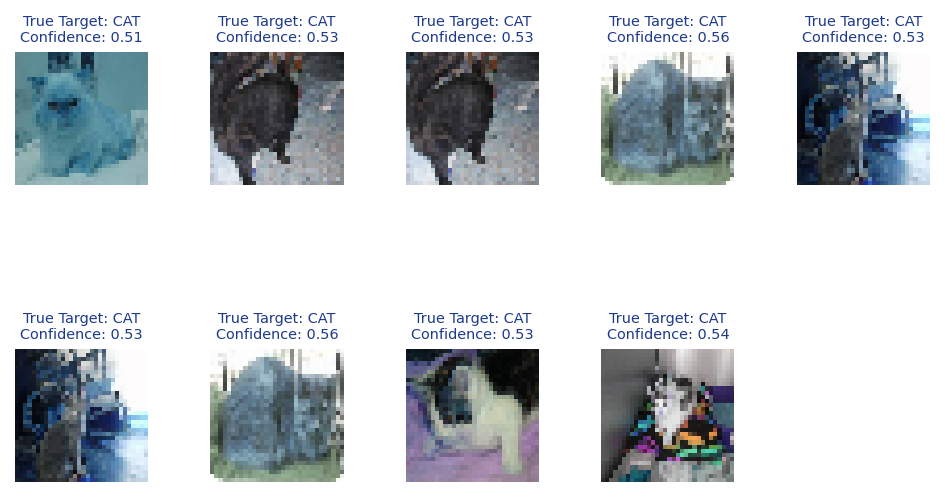

In [248]:
errors = int(df_err_cats.shape[0] * .1)
idx = df_err_cats[:errors].index
show_images(errors, df_test[idx], df_err_cats.loc[idx, :])

## Extra (para hacer en clase)
Repite los pasos 3 a 5 utilizando el generador de imágenes sintéticas o Image Augmentation de Keras.